# PDE Applications in Engineering – Micro-Project
## 1D Image Blurring Using the Heat Equation

**Course:** 24BSE2113-D – Partial Differential Equations, Transforms & Optimization Techniques

**Project:** 1D Image Blurring and Restoration Using the Heat Equation

This notebook implements the mathematical model developed in the assignment. Pixel intensity is treated as a diffusing quantity on a 1D scan line. The initial scan line is a step function, and homogeneous Neumann boundary conditions are used.

## 1. Objective

The objective is to demonstrate computationally how the one-dimensional heat equation models image blurring.

The assignment uses

$$\frac{\partial I}{\partial t}=\alpha\frac{\partial^2 I}{\partial x^2}$$

with the step-function initial condition

$$I(x,0)=\begin{cases}0,&0\le x<L/2\\1,&L/2\le x\le L\end{cases}$$

and homogeneous Neumann boundary conditions

$$I_x(0,t)=0,\qquad I_x(L,t)=0.$$

## 2. Libraries

We use NumPy for numerical computation and Matplotlib for visualization, as required for the computational micro-project.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)
print('Libraries loaded successfully.')

NumPy version: 2.1.3
Libraries loaded successfully.


## 3. Define the Physical and Numerical Parameters

- $L$: length of the 1D scan line
- $\alpha$: diffusion coefficient
- $N_x$: number of spatial samples
- $N$: number of Fourier modes used in the approximation

The Fourier solution is

$$I(x,t)=\frac12+\sum_{n=1}^{\infty}a_n\cos\left(\frac{n\pi x}{L}\right)e^{-\alpha(n\pi/L)^2t},$$

where

$$a_n=-\frac{2}{n\pi}\sin\left(\frac{n\pi}{2}\right).$$

In [ ]:
# Physical parameters
L = 1.0                 # Length of scan line
alpha = 0.10            # Diffusion coefficient

# Numerical parameters
Nx = 1000               # Number of spatial samples
N_modes = 100           # Number of Fourier modes

x = np.linspace(0, L, Nx)

print(f'L = {L}')
print(f'alpha = {alpha}')
print(f'Number of spatial samples = {Nx}')
print(f'Number of Fourier modes = {N_modes}')

L = 1.0
alpha = 0.1
Number of spatial samples = 1000
Number of Fourier modes = 100


## 4. Initial Step-Function Image

The left half of the scan line has intensity 0 and the right half has intensity 1. The discontinuity at $x=L/2$ represents a sharp image edge.

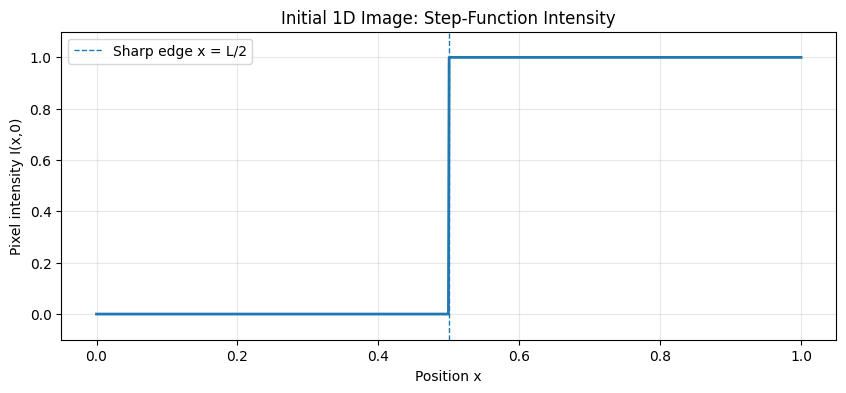

In [ ]:
# Initial condition: step function
I0 = np.where(x < L/2, 0.0, 1.0)

plt.figure(figsize=(10, 4))
plt.plot(x, I0, linewidth=2)
plt.axvline(L/2, linestyle='--', linewidth=1, label='Sharp edge x = L/2')
plt.xlabel('Position x')
plt.ylabel('Pixel intensity I(x,0)')
plt.title('Initial 1D Image: Step-Function Intensity')
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. Calculate the Fourier Coefficients

For the step-function initial condition, the assignment derives

$$a_0=1$$

and

$$a_n=-\frac{2}{n\pi}\sin\left(\frac{n\pi}{2}\right).$$

Therefore, even-indexed coefficients are zero, while odd-indexed coefficients alternate in sign.

In [ ]:
n = np.arange(1, N_modes + 1)

# Fourier coefficients from the analytical derivation
a0 = 1.0
an = -(2 / (n * np.pi)) * np.sin(n * np.pi / 2)

print('a0 =', a0)
print('\nFirst 20 Fourier coefficients:')
for k in range(20):
    print(f'n = {n[k]:2d}, a_n = {an[k]: .6f}')

a0 = 1.0

First 20 Fourier coefficients:
n =  1, a_n = -0.636620
n =  2, a_n = -0.000000
n =  3, a_n =  0.212207
n =  4, a_n =  0.000000
n =  5, a_n = -0.127324
n =  6, a_n = -0.000000
n =  7, a_n =  0.090946
n =  8, a_n =  0.000000
n =  9, a_n = -0.070736
n = 10, a_n = -0.000000
n = 11, a_n =  0.057875
n = 12, a_n =  0.000000
n = 13, a_n = -0.048971
n = 14, a_n = -0.000000
n = 15, a_n =  0.042441
n = 16, a_n =  0.000000
n = 17, a_n = -0.037448
n = 18, a_n = -0.000000
n = 19, a_n =  0.033506
n = 20, a_n =  0.000000


## 6. Implement the Fourier-Series Heat-Equation Solution

The computational function below evaluates

$$I(x,t)=\frac12+\sum_{n=1}^{N}a_n\cos\left(\frac{n\pi x}{L}\right)e^{-\alpha(n\pi/L)^2t}.$$

Increasing `N_modes` gives a better approximation to the sharp initial step.

In [ ]:
def heat_solution(x, t, L, alpha, N_modes=100):
    """Fourier-series solution of the 1D heat equation.

    I(x,t) = 1/2 + sum(a_n cos(n*pi*x/L)
                         exp(-alpha*(n*pi/L)^2*t))

    with a_n = -2/(n*pi) * sin(n*pi/2).
    """
    n = np.arange(1, N_modes + 1)
    coefficients = -(2 / (n * np.pi)) * np.sin(n * np.pi / 2)

    spatial = np.cos(np.outer(n * np.pi / L, x))
    decay = np.exp(-alpha * (n * np.pi / L)**2 * t)

    return 0.5 + np.sum(coefficients[:, None] * spatial * decay[:, None], axis=0)


## 7. Verify the Fourier Approximation at $t=0$

At $t=0$, all exponential factors are equal to 1. The finite Fourier series should therefore approximate the original step function, with the usual smoothing near the discontinuity caused by truncating the series.

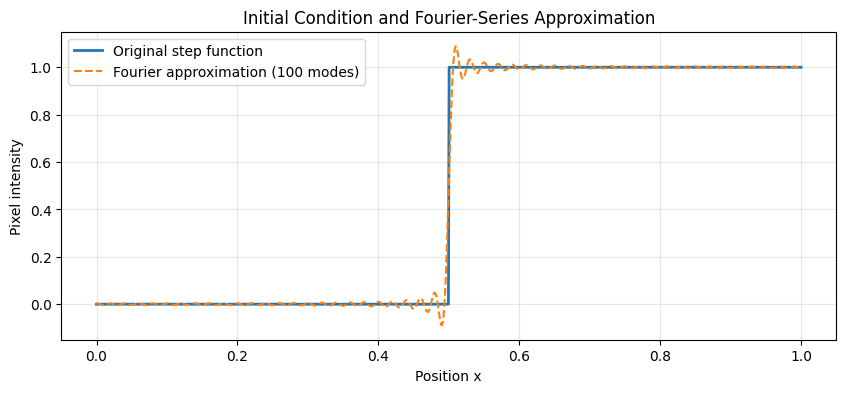

In [ ]:
I_fourier_0 = heat_solution(x, 0, L, alpha, N_modes)

plt.figure(figsize=(10, 4))
plt.plot(x, I0, linewidth=2, label='Original step function')
plt.plot(x, I_fourier_0, linestyle='--', linewidth=1.5,
         label=f'Fourier approximation ({N_modes} modes)')
plt.xlabel('Position x')
plt.ylabel('Pixel intensity')
plt.title('Initial Condition and Fourier-Series Approximation')
plt.ylim(-0.15, 1.15)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 8. Demonstrate Image Blurring at Different Times

As time increases, the diffusion process spreads intensity around the sharp edge. The edge therefore becomes smoother, representing image blurring.

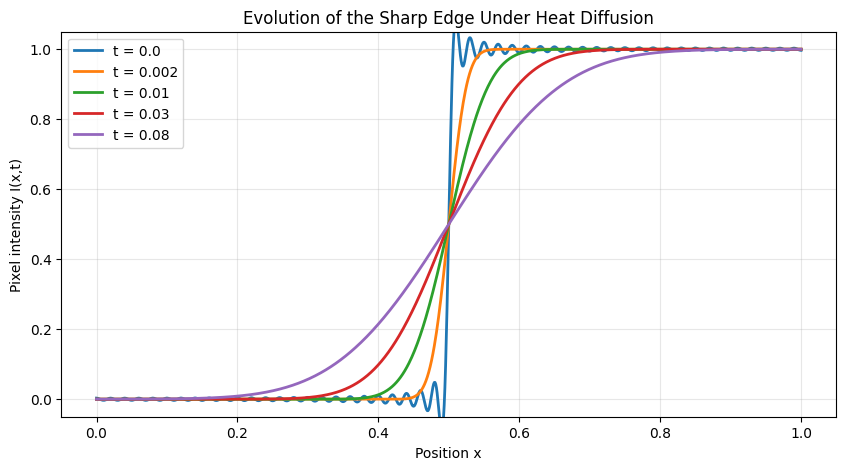

In [ ]:
times = [0.0, 0.002, 0.01, 0.03, 0.08]

plt.figure(figsize=(10, 5))

for t in times:
    I_t = heat_solution(x, t, L, alpha, N_modes)
    plt.plot(x, I_t, linewidth=2, label=f't = {t}')

plt.xlabel('Position x')
plt.ylabel('Pixel intensity I(x,t)')
plt.title('Evolution of the Sharp Edge Under Heat Diffusion')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 9. Visualize the Edge-Blurring Process More Clearly

This plot focuses on the region around the original edge $x=L/2$. It makes the transition from a sharp edge to a smooth intensity profile easier to observe.

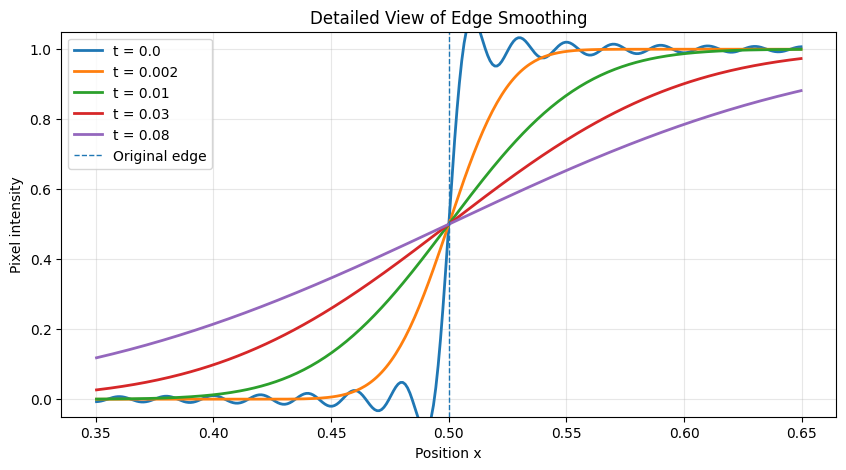

In [ ]:
edge_region = (x >= 0.35 * L) & (x <= 0.65 * L)

plt.figure(figsize=(10, 5))

for t in times:
    I_t = heat_solution(x, t, L, alpha, N_modes)
    plt.plot(x[edge_region], I_t[edge_region], linewidth=2, label=f't = {t}')

plt.axvline(L/2, linestyle='--', linewidth=1, label='Original edge')
plt.xlabel('Position x')
plt.ylabel('Pixel intensity')
plt.title('Detailed View of Edge Smoothing')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 10. Low-Pass Filtering: Fourier-Mode Decay

Each Fourier mode has the time-dependent factor

$$e^{-\alpha(n\pi/L)^2t}.$$

Because the exponent contains $n^2$, larger values of $n$ decay more rapidly. Thus high spatial-frequency components are suppressed more strongly than low-frequency components.

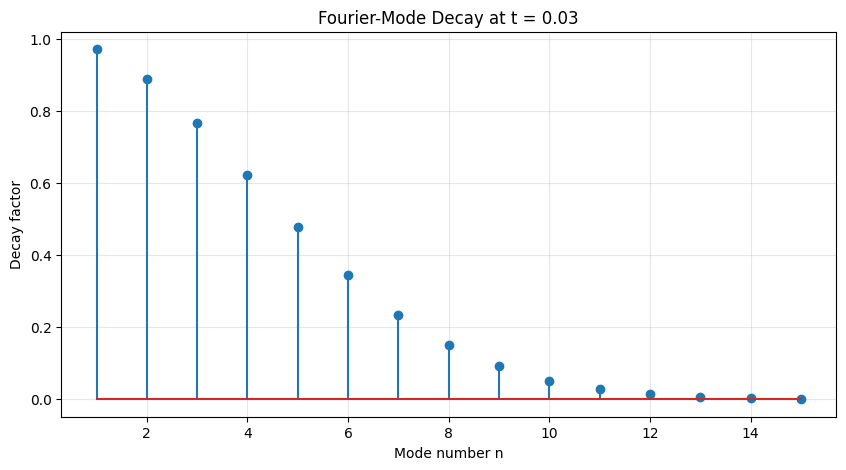

In [ ]:
modes_to_show = np.arange(1, 16)
t_decay = 0.03

decay_factors = np.exp(-alpha * (modes_to_show * np.pi / L)**2 * t_decay)

plt.figure(figsize=(10, 5))
plt.stem(modes_to_show, decay_factors)
plt.xlabel('Mode number n')
plt.ylabel('Decay factor')
plt.title(f'Fourier-Mode Decay at t = {t_decay}')
plt.grid(True, alpha=0.3)
plt.show()

### Compare the first and third modes

For $n=1$:

$$e^{-\alpha\pi^2t/L^2}$$

For $n=3$:

$$e^{-9\alpha\pi^2t/L^2}$$

The factor 9 comes from $3^2=9$, so the third mode decays much faster than the first mode.

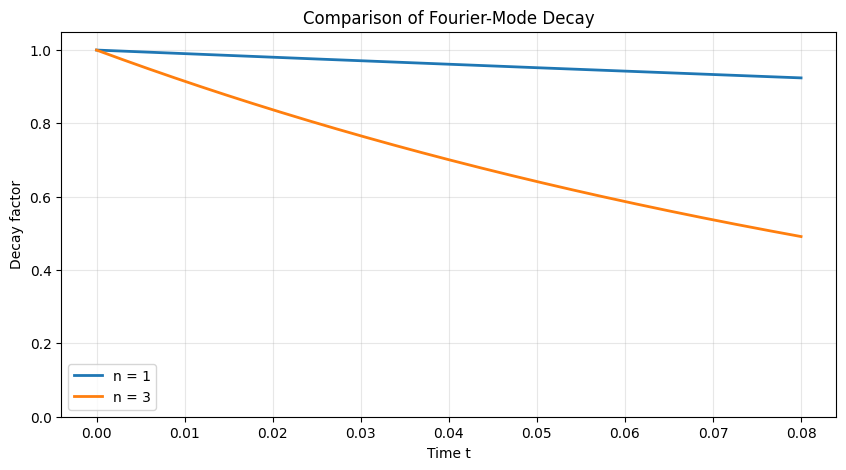

In [ ]:
t_values = np.linspace(0, 0.08, 300)

decay_n1 = np.exp(-alpha * (1 * np.pi / L)**2 * t_values)
decay_n3 = np.exp(-alpha * (3 * np.pi / L)**2 * t_values)

plt.figure(figsize=(10, 5))
plt.plot(t_values, decay_n1, linewidth=2, label='n = 1')
plt.plot(t_values, decay_n3, linewidth=2, label='n = 3')
plt.xlabel('Time t')
plt.ylabel('Decay factor')
plt.title('Comparison of Fourier-Mode Decay')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 11. Quantitative Check of High-Frequency Suppression

The following calculation compares the decay factors of selected modes at the same time. This provides numerical evidence for the low-pass filtering behaviour.

In [ ]:
selected_modes = np.array([1, 3, 5, 10, 20, 50, 100])
t_check = 0.03

selected_decay = np.exp(-alpha * (selected_modes * np.pi / L)**2 * t_check)

print(f'Decay factors at t = {t_check}:\n')
for mode, factor in zip(selected_modes, selected_decay):
    print(f'n = {mode:3d}  ->  decay factor = {factor:.6e}')

Decay factors at t = 0.03:

n =   1  ->  decay factor = 9.708252e-01
n =   3  ->  decay factor = 7.660718e-01
n =   5  ->  decay factor = 4.770088e-01
n =  10  ->  decay factor = 5.177327e-02
n =  20  ->  decay factor = 7.184926e-06
n =  50  ->  decay factor = 7.122616e-33
n = 100  ->  decay factor = 2.573701e-129


## 12. Effect of the Number of Fourier Modes

A finite number of modes is used in computation. The following comparison shows how the Fourier approximation changes as the number of modes is increased.

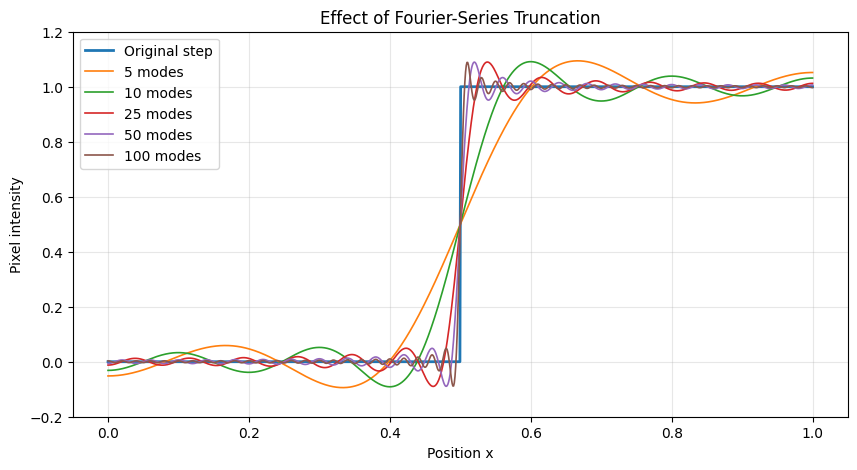

In [ ]:
mode_counts = [5, 10, 25, 50, 100]

plt.figure(figsize=(10, 5))
plt.plot(x, I0, linewidth=2, label='Original step')

for count in mode_counts:
    I_approx = heat_solution(x, 0, L, alpha, count)
    plt.plot(x, I_approx, linewidth=1.2, label=f'{count} modes')

plt.xlabel('Position x')
plt.ylabel('Pixel intensity')
plt.title('Effect of Fourier-Series Truncation')
plt.ylim(-0.2, 1.2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 13. Engineering Interpretation

The numerical results demonstrate the mathematical conclusions of the assignment:

1. The initial step function represents a sharp image edge.
2. Heat diffusion spreads intensity into neighbouring positions.
3. The sharp transition becomes progressively smoother as time increases.
4. Every Fourier component is multiplied by an exponential decay factor.
5. The decay rate depends on $n^2$, so higher spatial-frequency components disappear faster.
6. Since sharp edges contain significant high-frequency information, their attenuation produces image blurring.
7. Therefore, the heat equation behaves as a low-pass filter.

## 14. Final Fourier-Series Solution

For the step-function initial condition, the final analytical solution used in this notebook is

$$\boxed{I(x,t)=\frac12-\sum_{n=1}^{\infty}\frac{2}{n\pi}\sin\left(\frac{n\pi}{2}\right)\cos\left(\frac{n\pi x}{L}\right)e^{-\alpha(n\pi/L)^2t}}$$

In computation, the infinite series is truncated to a finite number of modes.

## 15. Conclusion

The one-dimensional heat equation successfully models the diffusion of pixel intensity along an image scan line. The computational Fourier-series solution shows that a sharp edge becomes progressively smoother as time increases. The exponential factor contains $n^2$, causing higher spatial-frequency components to decay faster than lower-frequency components. This demonstrates the low-pass filtering behaviour of the heat equation and explains the resulting image-blurring effect.

## References

1. Saintgits College of Engineering (Autonomous), Department of Electronics and Communication Engineering, Group Assignment & Micro-Project–1: PDE Applications in Engineering, Course 24BSE2113-D.
2. Course material on the one-dimensional heat equation, separation of variables, boundary value problems, and Fourier-series solutions.